In [1]:
import pickle as pk
import numpy as np
import matplotlib.pyplot as pl
# pl.rc('text', usetex=True)
%matplotlib inline
import os
import sys, os
# os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
# from jax.lib import xla_bridge
# platform = xla_bridge.get_backend().platform
# import jax
# import jax.numpy as jnp
# from jax import vmap, grad, pmap
# print(jax.local_device_count(), jax.device_count())
# jax.config.update('jax_platform_name', platform)
# jax.config.update("jax_enable_x64", True)

# import pathlib
# curr_path = pathlib.Path().absolute()
# abs_path_data = os.path.abspath(curr_path / "../../data/") 
# abs_path_src = os.path.abspath(curr_path / "../../src/") 
# abs_path_results = os.path.abspath(curr_path / "../../results/") 
# abs_path_params = os.path.abspath(curr_path / "../../param_files/") 
# sys.path.append((curr_path))
# sys.path.append((abs_path_data))
# sys.path.append((abs_path_results))
# sys.path.append(abs_path_src)

# # from jax import config
# import scipy.interpolate as interp
# import pickle as pk
# import numpy as np
# import colossus 
# import configobj

# from base_class import base_class
# from get_radial_profiles import Profiles
# from get_Pkzs import get_Pkz
# from get_Cls import get_Cl
# from get_Xis import get_xi
# from get_covs import get_cov

import jax


In [2]:
# !pip install jax

In [3]:
# # saved = {'Pmm_ratio_all_samp': Pmm_ratio_all_samp, 'Pmin': Pmin, 'Pmax': Pmax, 'k_array': np.array(Pkz_test.kPk_array)}
# # pk.dump(saved, open(abs_path_results + f'/DESxACT/plot_data/Pksup_plot_data_nsamps_512_v10_{probe}_probes_widemuej.pkl','wb'))
# import pickle as pk
# import numpy as np
# probe = 'all'
# # saved = pk.load(open(abs_path_results + f'/DESxACT/plot_data/Pksup_plot_data_nsamps_512_v10_{probe}_probes_widemuej.pkl','rb'))
# abs_path_results = '/projects/bdne/spandey3/new_godmax/GODMAX/results/'
# # saved = pk.load(open(abs_path_results + '/DESxACT/plot_data/Pksup_plot_data_nsamps_5000_v10_all_probes_widemuej.pkl','rb')) 
# # Pmm_ratio_all_samp1 = saved['Pmm_ratio_all_samp']
# # Pmin = saved['Pmin']
# # Pmax = saved['Pmax']
# # k_array = saved['k_array']

# # saved = pk.load(open(abs_path_results + '/DESxACT/plot_data/Pksup_plot_data_nsamps_6000_v10_all_probes_widemuej.pkl','rb')) 
# # Pmm_ratio_all_samp2 = saved['Pmm_ratio_all_samp']

# # saved = pk.load(open(abs_path_results + '/DESxACT/plot_data/Pksup_plot_data_nsamps_4000_v10_all_probes_widemuej.pkl','rb')) 
# # Pmm_ratio_all_samp3 = saved['Pmm_ratio_all_samp']

# saved = pk.load(open(abs_path_results + '/DESxACT/plot_data/Pksup_YMerr_plot_data_nsamps_5000_v11_all_probes_widemuej.pkl','rb')) 
# Pmm_ratio_all_samp4 = saved['Pmm_ratio_all_samp']
# indsel4 = saved['indsel']
# k_array = saved['k_array']

# saved = pk.load(open(abs_path_results + '/DESxACT/plot_data/Pksup_YMerr_plot_data_nsamps_6000_v11_all_probes_widemuej.pkl','rb')) 
# indsel5 = saved['indsel']
# Pmm_ratio_all_samp5 = saved['Pmm_ratio_all_samp']

# saved = pk.load(open(abs_path_results + '/DESxACT/plot_data/Pksup_YMerr_plot_data_nsamps_7000_v11_all_probes_widemuej.pkl','rb')) 
# indsel6 = saved['indsel']
# Pmm_ratio_all_samp6 = saved['Pmm_ratio_all_samp']

# saved = pk.load(open(abs_path_results + '/DESxACT/plot_data/Pksup_YMerr_plot_data_nsamps_8000_v11_all_probes_widemuej.pkl','rb')) 
# indsel7 = saved['indsel']
# Pmm_ratio_all_samp7 = saved['Pmm_ratio_all_samp']


# # Pmm_ratio_all_samp = np.concatenate((Pmm_ratio_all_samp1, Pmm_ratio_all_samp2, Pmm_ratio_all_samp3, Pmm_ratio_all_samp4, Pmm_ratio_all_samp5, Pmm_ratio_all_samp6, Pmm_ratio_all_samp7), axis=0)
# indsel = np.concatenate((indsel4, indsel5, indsel6, indsel7), axis=0)
# indsel_uq, indsel_sel = np.unique(indsel, return_index=True)
# Pmm_ratio_all_samp = np.concatenate((Pmm_ratio_all_samp4, Pmm_ratio_all_samp5, Pmm_ratio_all_samp6, Pmm_ratio_all_samp7), axis=0)
# Pmm_ratio_all_samp = Pmm_ratio_all_samp[indsel_sel]
# print(Pmm_ratio_all_samp.shape, indsel.shape, indsel_uq.shape)


In [4]:
# saved = {'Pmm_ratio_all_samp': Pmm_ratio_all_samp, 'Pmin': Pmin, 'Pmax': Pmax, 'k_array': np.array(Pkz_test.kPk_array)}
# pk.dump(saved, open(abs_path_results + f'/DESxACT/plot_data/Pksup_plot_data_nsamps_512_v10_{probe}_probes_widemuej.pkl','wb'))
import pickle as pk
import numpy as np
probe = 'all'
# saved = pk.load(open(abs_path_results + f'/DESxACT/plot_data/Pksup_plot_data_nsamps_512_v10_{probe}_probes_widemuej.pkl','rb'))
abs_path_results = '/projects/bdne/spandey3/new_godmax/GODMAX/results/'
# saved = pk.load(open(abs_path_results + '/DESxACT/plot_data/Pksup_YMerr_plot_data_nsamps_5000_v11_all_probes_widemuej.pkl','rb')) 
saved = pk.load(open(abs_path_results + f'/DESxACT/plot_data/Pksup_YMerr_v12_maskPS_True_plot_data_nsamps_6000_v12_all_probes.pkl','rb'))
Pmm_ratio_all_samp = saved['Pmm_ratio_all_samp']
indsel = saved['indsel']
k_array = saved['k_array']

# # Pmm_ratio_all_samp = np.concatenate((Pmm_ratio_all_samp1, Pmm_ratio_all_samp2, Pmm_ratio_all_samp3, Pmm_ratio_all_samp4, Pmm_ratio_all_samp5, Pmm_ratio_all_samp6, Pmm_ratio_all_samp7), axis=0)
# indsel = np.concatenate((indsel4, indsel5, indsel6, indsel7), axis=0)
# indsel_uq, indsel_sel = np.unique(indsel, return_index=True)
# Pmm_ratio_all_samp = np.concatenate((Pmm_ratio_all_samp4, Pmm_ratio_all_samp5, Pmm_ratio_all_samp6, Pmm_ratio_all_samp7), axis=0)
# Pmm_ratio_all_samp = Pmm_ratio_all_samp[indsel_sel]
# print(Pmm_ratio_all_samp.shape, indsel.shape, indsel_uq.shape)


In [5]:
pksup_owls = np.loadtxt('/projects/bdne/spandey3/new_godmax/GODMAX/data/DESxACT/pk_sup_owls8p5.txt')
pksup_mtng = np.loadtxt('/projects/bdne/spandey3/new_godmax/GODMAX/data/DESxACT/pk_sup_mtng.txt')
pksup_flamingo = np.loadtxt('/projects/bdne/spandey3/new_godmax/GODMAX/data/DESxACT/pk_sup_flamingo.txt')
# pksup_owls.shape
import scipy.interpolate as interp
pksup_owls_interp = interp.interp1d(pksup_owls[:,0], pksup_owls[:,1], fill_value=1.0, bounds_error=False)
pksup_mtng_interp = interp.interp1d(pksup_mtng[:,0], pksup_mtng[:,1], fill_value=1.0, bounds_error=False)
pksup_flamingo_interp = interp.interp1d(pksup_flamingo[:,0], pksup_flamingo[:,1], fill_value=1.0, bounds_error=False)



In [6]:
# Pmm_ratio_all_samp.shape
# indsel = np.where((k_array > 0.01) & (k_array < 4))[0][::5][-4:]
# indsel = np.where((k_array > 0.005) & (k_array < 5))[0][-18:-1][::6]

##### indsel = np.where((k_array > 0.005) & (k_array < 5))[0][-22:-1][::6]
indsel = np.where((k_array > 0.3) & (k_array < 3))[0][::3]

# indsel = np.where((k_array > 0.01) & (k_array < 5))[0][-18:-1][::5]

# indsel = np.where((k_array > 0.4) & (k_array < 4))[0][::2]
# print(len(indsel)
kval_sel = k_array[indsel]
Pmm_ratio_all_samp_sel = Pmm_ratio_all_samp[:,indsel]

pksup_owls_sel = pksup_owls_interp(kval_sel)
pksup_mtng_sel = pksup_mtng_interp(kval_sel)
pksup_flamingo_sel = pksup_flamingo_interp(kval_sel)


In [7]:
len(np.where((k_array > 0.1) & (k_array < 5))[0])


26

In [8]:
diff_samps1 = Pmm_ratio_all_samp_sel - pksup_mtng_sel[None,:]
diff_samps2 = Pmm_ratio_all_samp_sel - pksup_flamingo_sel[None,:]
diff_samps3 = Pmm_ratio_all_samp_sel - pksup_owls_sel[None,:]

diff_mean1 = np.mean(diff_samps1, axis=0)[None,:]
diff_cov1 = np.cov(diff_samps1.T)

diff_mean2 = np.mean(diff_samps2, axis=0)[None,:]
diff_cov2 = np.cov(diff_samps2.T)

diff_mean3 = np.mean(diff_samps3, axis=0)[None,:]
diff_cov3 = np.cov(diff_samps3.T)

import numpy as np
import scipy.stats as stats

def chi2_per_dof_to_sigma(chi2_per_dof, dof):
    # Calculate total chi-square
    chi2 = chi2_per_dof * dof
    
    # Calculate p-value (upper tail probability)
    p_value = 1 - stats.chi2.cdf(chi2, dof)
    
    # Convert to sigma (standard deviations)
    sigma = stats.norm.ppf(1 - p_value/2)
    
    return sigma

chi2_diff1 = np.matmul(diff_mean1, np.matmul(np.linalg.inv(diff_cov1), diff_mean1.T))
chi2_diff2 = np.matmul(diff_mean2, np.matmul(np.linalg.inv(diff_cov2), diff_mean2.T))
chi2_diff3 = np.matmul(diff_mean3, np.matmul(np.linalg.inv(diff_cov3), diff_mean3.T))

chi2_per_dof = np.array([chi2_diff1, chi2_diff2, chi2_diff3]) / (len(kval_sel) - 1)

sigma_value = chi2_per_dof_to_sigma(chi2_per_dof, len(kval_sel) - 1)

print(chi2_per_dof,  np.sqrt(2/(len(kval_sel)-1)))
print(sigma_value)

# np.amin(diff), np.amax(diff)
# np.all(np.isfinite(diff))
# chi2_diff = np.matmul(diff_chain)


[[[5.56967647]]

 [[2.82592808]]

 [[0.42980988]]] 0.7071067811865476
[[[3.75065307]]

 [[2.26758315]]

 [[0.26992254]]]


In [ ]:


# chi2_per_dof_to_sigma(5.6, 4)




np.float64(3.7645860820261343)

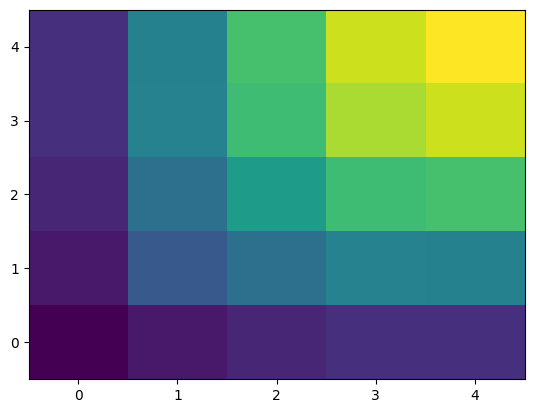

In [111]:
# diff_mean3
# np.matmul(diff_mean3, np.matmul(np.linalg.inv(np.diag(np.diag(diff_cov3))), diff_mean3.T))
pl.figure()
pl.imshow(diff_cov3, origin='lower', aspect='auto')


In [112]:
Pmm_ratio_all_samp_sel_mean = np.mean(Pmm_ratio_all_samp_sel, axis=0)
Pmm_ratio_all_samp_sel_cov = np.cov(Pmm_ratio_all_samp_sel.T)


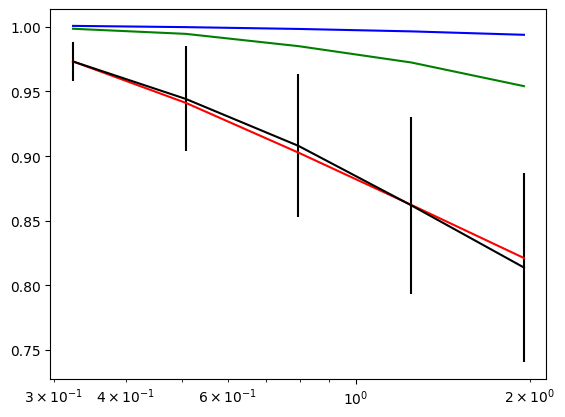

In [113]:
# Pmm_ratio_all_samp_sel_cov.shape
# %matplotlib inline
pl.figure()
pl.errorbar(kval_sel, Pmm_ratio_all_samp_sel_mean, np.sqrt(np.diag(Pmm_ratio_all_samp_sel_cov)), color='k', label='Mean')
pl.plot(kval_sel, pksup_owls_sel, color='r', label='OWLS')
pl.plot(kval_sel, pksup_mtng_sel, color='b', label='MTNG')
pl.plot(kval_sel, pksup_flamingo_sel, color='g', label='Flamingo')
pl.xscale('log')


In [125]:
# pk_diff_mtng_samp
# Pmm_ratio_all_samp_sel.shape
# pk_diff_mtng_samp.shape\
import getdist
from getdist import plots, MCSamples

diff_chain = MCSamples(samples=Pmm_ratio_all_samp_sel - pksup_mtng_sel[None,:])
# diff_chain = MCSamples(samples=Pmm_ratio_all_samp_sel - pksup_flamingo_sel[None,:])
# diff_chain = MCSamples(samples=Pmm_ratio_all_samp_sel - pksup_owls_sel[None,:])




In [126]:
# Pmm_ratio_all_samp_sel.shape


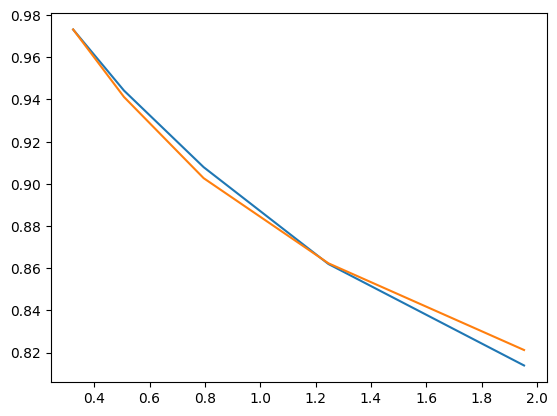

In [127]:
pl.figure()
# pl.plot(kval_sel, diff_mean[0,:])
pl.plot(kval_sel, np.mean(Pmm_ratio_all_samp_sel, axis=0))
pl.plot(kval_sel, pksup_owls_sel)


In [128]:
# # diff_cov.shape, diff_samps.shape, chi2_diff.shape
# pl.figure()
# pl.imshow(diff_cov, origin='lower', interpolation='nearest', cmap='viridis')


<Figure size 625x625 with 0 Axes>

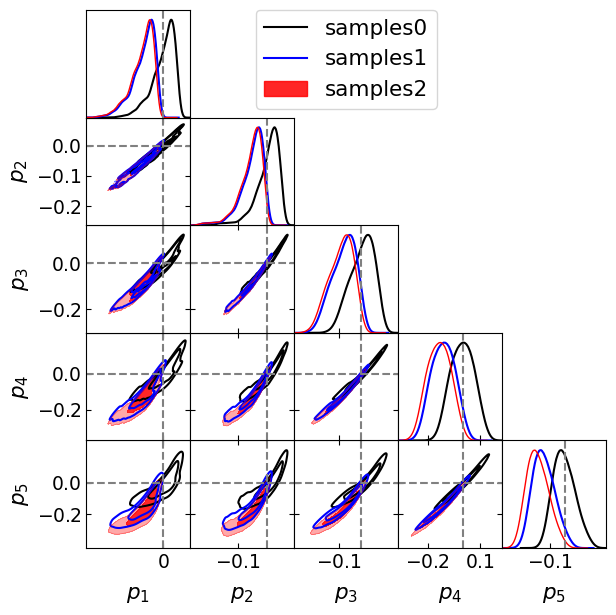

In [129]:
import getdist
from getdist import plots, MCSamples
# samples = MCSamples(samples=Pmm_ratio_all_samp_sel)
g = plots.getSinglePlotter(width_inch=6.25, ratio=1.0)
# g.settings.auto_ticks = True
g.settings.axes_fontsize   = 18
g.settings.lab_fontsize    = 20
g.settings.legend_fontsize = 20
g.settings.axis_marker_lw = 1.5
g.settings.num_plot_contours = 2

diff_chain_owls = MCSamples(samples=Pmm_ratio_all_samp_sel - pksup_owls_sel[None,:])
diff_chain_flamingo = MCSamples(samples=Pmm_ratio_all_samp_sel - pksup_flamingo_sel[None,:])
diff_chain_mtng = MCSamples(samples=Pmm_ratio_all_samp_sel - pksup_mtng_sel[None,:])


g.triangle_plot([diff_chain_owls, diff_chain_flamingo, diff_chain_mtng], 
            contour_lws=[1.5, 1.5, 1.0], filled = [False, False,True, True, True], contour_colors = ['black','blue','red','orange','green'],
            ls=['-','-','','',''], markers=np.zeros(Pmm_ratio_all_samp_sel.shape[-1]))
import matplotlib
%matplotlib inline
pl.show()



In [130]:
import tensiometer
# from tensiometer.utilities import stats_utilities as utilities
from tensiometer import mcmc_tension
import tensiometer.utilities as utilities




In [131]:
# utilities.stats_utilities
# utilities.from_confidence_to_sigma
shift_P, shift_low, shift_hi = mcmc_tension.kde_parameter_shift(diff_chain, feedback=10)

# print the results:
print(f'Shift probability considering all parameters:\n',
      f'   P = {shift_P:.5f} +{shift_hi-shift_P:.5f} -{shift_P-shift_low:.5f}')
# turn the result to effective number of sigmas:
print(f'    n_sigma = {utilities.from_confidence_to_sigma(shift_P):.3f}',
      f'+{utilities.from_confidence_to_sigma(shift_hi)-utilities.from_confidence_to_sigma(shift_P):.3f}',
      f'-{utilities.from_confidence_to_sigma(shift_P)-utilities.from_confidence_to_sigma(shift_low):.3f}')

      

Dimension       : 5
N    samples    : 4251
Neff samples    : 4251.00
Smoothing scale : [0.154 0.154 0.154 0.154 0.154]
Building KD-Tree with leafsize = 400
Neighbours elimination
neighbor_elimination: chunk 1
    surviving elements 0 of 4251
neighbor_elimination: chunk 2
    surviving elements 0 of 4251
neighbor_elimination: polishing


0it [00:00, ?it/s]

    surviving elements 0 of 4251


KDE method: neighbor_elimination
Time taken for KDE calculation: 0.0 (s)
Shift probability considering all parameters:
    P = 1.00000 +nan -0.00043
    n_sigma = inf +nan -inf


In [132]:
shift_P, shift_low, shift_hi = mcmc_tension.kde_parameter_shift(diff_chain, scale='MISE', feedback=0)

# print the results:
print(f'Shift probability considering all parameters:\n',
      f'   P = {shift_P:.5f} +{shift_hi-shift_P:.5f} -{shift_P-shift_low:.5f}')
# turn the result to effective number of sigmas:
print(f'    n_sigma = {utilities.from_confidence_to_sigma(shift_P):.3f}',
      f'+{utilities.from_confidence_to_sigma(shift_hi)-utilities.from_confidence_to_sigma(shift_P):.3f}',
      f'-{utilities.from_confidence_to_sigma(shift_P)-utilities.from_confidence_to_sigma(shift_low):.3f}')

      

Shift probability considering all parameters:
    P = 1.00000 +nan -0.00043
    n_sigma = inf +nan -inf


In [133]:
shift_P, shift_low, shift_hi = mcmc_tension.kde_parameter_shift(diff_chain, scale='AMISE', feedback=0)

# print the results:
print(f'Shift probability considering all parameters:\n',
      f'   P = {shift_P:.5f} +{shift_hi-shift_P:.5f} -{shift_P-shift_low:.5f}')
# turn the result to effective number of sigmas:
print(f'    n_sigma = {utilities.from_confidence_to_sigma(shift_P):.3f}',
      f'+{utilities.from_confidence_to_sigma(shift_hi)-utilities.from_confidence_to_sigma(shift_P):.3f}',
      f'-{utilities.from_confidence_to_sigma(shift_P)-utilities.from_confidence_to_sigma(shift_low):.3f}')
      

Shift probability considering all parameters:
    P = 1.00000 +nan -0.00043
    n_sigma = inf +nan -inf


In [134]:
# !pip install numpy==1.26.0


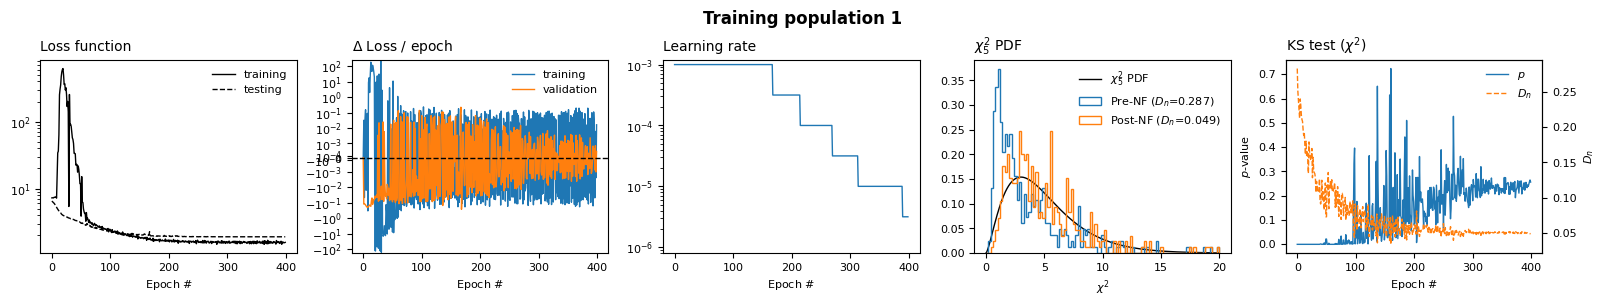

20/20 - 1s - loss: 1.5707 - val_loss: 1.9034 - lr: 3.1623e-06 - 1s/epoch - 53ms/step
* Population optimizer:
    - best model is number 1
    - best loss function is 1.57
    - best validation loss function is 1.9
    - population losses [1.9]
Shift probability considering all parameters:
    P = 0.00000 +nan --0.00002
    n_sigma = 0.000 +nan --0.000


In [135]:
# import tensiometer
import sys, os
os.environ['TF_USE_LEGACY_KERAS'] = "1"
from tensiometer import mcmc_tension
from getdist import MCSamples
import numpy as np
# diff_chain = MCSamples(samples=np.random.randn(1000,10))
kwargs = {
          'feedback': 2,  # verbosity level
          'pop_size': 1,  # controls the number of flows that are trained. The best one is then selected. Since time to solution scales linearly with pop_size, it is a good idea to set it to 1 for a first run. 
          'epochs':400,
          'plot_every': 50
        }

# call the helper function:
results, diff_flow = mcmc_tension.flow_parameter_shift(diff_chain,   # parameter difference chain
                                      cache_dir=None,  # directory where the trained flow is saved, to save time next time
                                      root_name='sprob',  # name of the cached flow (usefull to have several in the same folder)
                                      **kwargs
                                      )

# unpack results:
shift_P, shift_hi, shift_low = results

# from tensiometer.utilities import stats_utilities as utilities
import tensiometer.utilities as utilities
print(f'Shift probability considering all parameters:\n',
      f'   P = {shift_P:.5f} +{shift_hi-shift_P:.5f} -{shift_P-shift_low:.5f}')
# turn the result to effective number of sigmas:
print(f'    n_sigma = {utilities.from_confidence_to_sigma(shift_P):.3f}',
      f'+{utilities.from_confidence_to_sigma(shift_hi)-utilities.from_confidence_to_sigma(shift_P):.3f}',
      f'-{utilities.from_confidence_to_sigma(shift_P)-utilities.from_confidence_to_sigma(shift_low):.3f}')
      


In [ ]:
# results


(0.9998285714285714,
 np.float64(0.9998115440097717),
 np.float64(0.999844116328359))

In [ ]:
# saved = pk.load(open(abs_path_results + '/DESxACT/plot_data/Pksup_YMerr_plot_data_nsamps_5000_v11_all_probes_widemuej.pkl','rb')) 
# YM_ratio_all_samp4 = saved['YM_ratio_all_samp']

# saved = pk.load(open(abs_path_results + '/DESxACT/plot_data/Pksup_YMerr_plot_data_nsamps_6000_v11_all_probes_widemuej.pkl','rb')) 
# YM_ratio_all_samp5 = saved['YM_ratio_all_samp']

# saved = pk.load(open(abs_path_results + '/DESxACT/plot_data/Pksup_YMerr_plot_data_nsamps_7000_v11_all_probes_widemuej.pkl','rb')) 
# YM_ratio_all_samp6 = saved['YM_ratio_all_samp']

# saved = pk.load(open(abs_path_results + '/DESxACT/plot_data/Pksup_YMerr_plot_data_nsamps_8000_v11_all_probes_widemuej.pkl','rb')) 
# YM_ratio_all_samp7 = saved['YM_ratio_all_samp']

# YM_ratio_all_samp = np.concatenate((YM_ratio_all_samp4, YM_ratio_all_samp5, YM_ratio_all_samp6, YM_ratio_all_samp7), axis=0)

# M_array = saved['M_array']


In [22]:
saved = pk.load(open(abs_path_results + f'/DESxACT/plot_data/Pksup_YMerr_v12_maskPS_True_plot_data_nsamps_6000_v12_all_probes.pkl','rb'))
YM_ratio_all_samp = saved['YM_ratio_all_samp']

M_array = saved['M_array']



In [130]:
indsel = np.where((M_array > 1e13) & (M_array < 1e15))[0][::4]
YM_ratio_all_samp_sel = YM_ratio_all_samp[:,indsel]
M_array_sel = M_array[indsel]
np.log10(M_array_sel)



array([13.065217, 13.76087 , 14.456522], dtype=float32)

In [131]:
# YM_ratio_all_samp_sel.shape
Ymin = np.percentile(YM_ratio_all_samp_sel, 16, axis=0)
Ymax = np.percentile(YM_ratio_all_samp_sel, 84, axis=0)


In [132]:
# saved = {'Y_B12_all': Y_B12_all, 'Y_owls_all_ref': Y_owls_all_ref, 'Y_owls_all_agn': Y_owls_all_agn, 'M_array': M_array}
# pk.dump(saved, open(abs_path_results + f'/DESxACT/plot_data/YM_plot_data_owls_battaglia.pkl','wb'))
saved = pk.load(open(abs_path_results + f'/DESxACT/plot_data/YM_plot_data_owls_battaglia.pkl','rb'))
Y_B12_all = saved['Y_B12_all']
Y_owls_all_ref = saved['Y_owls_all_ref']
Y_owls_all_agn = saved['Y_owls_all_agn']
M_array = saved['M_array']

Y_B12_interp = interp.interp1d(np.log(M_array), np.log(Y_B12_all), fill_value=1.0, bounds_error=False)
Y_owls_ref_interp = interp.interp1d(np.log(M_array), np.log(Y_owls_all_ref), fill_value=1.0, bounds_error=False)
Y_owls_agn_interp = interp.interp1d(np.log(M_array), np.log(Y_owls_all_agn), fill_value=1.0, bounds_error=False)

Y_B12_sel = np.exp(Y_B12_interp(np.log(M_array_sel)))
Y_owls_ref_sel = np.exp(Y_owls_ref_interp(np.log(M_array_sel)))
Y_owls_agn_sel = np.exp(Y_owls_agn_interp(np.log(M_array_sel)))



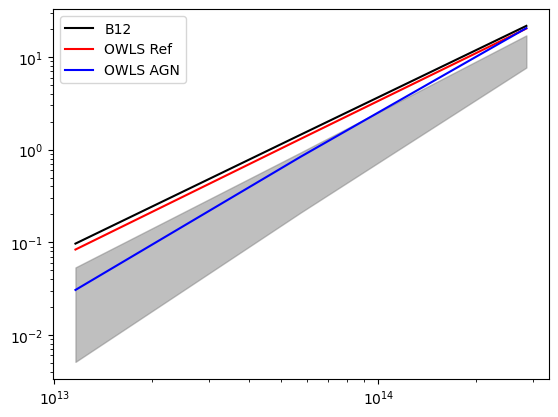

In [133]:
pl.figure()
pl.plot(M_array_sel, Y_B12_sel, color='k', label='B12')
pl.plot(M_array_sel, Y_owls_ref_sel, color='r', label='OWLS Ref')
pl.plot(M_array_sel, Y_owls_agn_sel, color='b', label='OWLS AGN')
pl.fill_between(M_array_sel, Ymin, Ymax, color='gray', alpha=0.5)
pl.xscale('log')
pl.yscale('log')
pl.legend()


In [134]:
# diff_samps1 = YM_ratio_all_samp_sel - Y_B12_sel[None,:]
# diff_samps2 = YM_ratio_all_samp_sel - Y_owls_ref_sel[None,:]
# diff_samps3 = YM_ratio_all_samp_sel - Y_owls_agn_sel[None,:]

# diff_samps1 = np.log10(YM_ratio_all_samp_sel) - np.log10(Y_B12_sel[None,:])
# diff_samps2 = np.log10(YM_ratio_all_samp_sel) - np.log10(Y_owls_ref_sel[None,:])
# diff_samps3 = np.log10(YM_ratio_all_samp_sel) - np.log10(Y_owls_agn_sel[None,:])


diff_samps1 = YM_ratio_all_samp_sel/((M_array_sel/1e15)**(5/3)) - Y_B12_sel[None,:]/((M_array_sel/1e15)**(5/3))
diff_samps2 = YM_ratio_all_samp_sel/((M_array_sel/1e15)**(5/3)) - Y_owls_ref_sel[None,:]/((M_array_sel/1e15)**(5/3))
diff_samps3 = YM_ratio_all_samp_sel/((M_array_sel/1e15)**(5/3)) - Y_owls_agn_sel[None,:]/((M_array_sel/1e15)**(5/3))



In [135]:
# diff_samps1 = Pmm_ratio_all_samp_sel - pksup_mtng_sel[None,:]
# diff_samps2 = Pmm_ratio_all_samp_sel - pksup_flamingo_sel[None,:]
# diff_samps3 = Pmm_ratio_all_samp_sel - pksup_owls_sel[None,:]

diff_mean1 = np.mean(diff_samps1, axis=0)[None,:]
diff_cov1 = np.cov(diff_samps1.T)

diff_mean2 = np.mean(diff_samps2, axis=0)[None,:]
diff_cov2 = np.cov(diff_samps2.T)

diff_mean3 = np.mean(diff_samps3, axis=0)[None,:]
diff_cov3 = np.cov(diff_samps3.T)

import numpy as np
import scipy.stats as stats

def chi2_per_dof_to_sigma(chi2_per_dof, dof):
    # Calculate total chi-square
    chi2 = chi2_per_dof * dof
    
    # Calculate p-value (upper tail probability)
    p_value = 1 - stats.chi2.cdf(chi2, dof)
    
    # Convert to sigma (standard deviations)
    sigma = stats.norm.ppf(1 - p_value/2)
    
    return sigma

chi2_diff1 = np.matmul(diff_mean1, np.matmul(np.linalg.inv(diff_cov1), diff_mean1.T))
chi2_diff2 = np.matmul(diff_mean2, np.matmul(np.linalg.inv(diff_cov2), diff_mean2.T))
chi2_diff3 = np.matmul(diff_mean3, np.matmul(np.linalg.inv(diff_cov3), diff_mean3.T))

chi2_per_dof = np.array([chi2_diff1, chi2_diff2, chi2_diff3]) / (diff_samps1.shape[1] - 1)

sigma_value = chi2_per_dof_to_sigma(chi2_per_dof, diff_samps1.shape[1] - 1)

# print(chi2_per_dof,  np.sqrt(2/(len(kval_sel)-1)))
print(sigma_value)

# np.amin(diff), np.amax(diff)
# np.all(np.isfinite(diff))
# chi2_diff = np.matmul(diff_chain)




[[[2.05319872]]

 [[1.5505601 ]]

 [[1.89360682]]]


In [121]:
chi2_per_dof


array([[[1.16209553]],

       [[0.92046451]],

       [[1.2389211 ]]])

Removed no burn in
Removed no burn in
Removed no burn in


<Figure size 625x625 with 0 Axes>

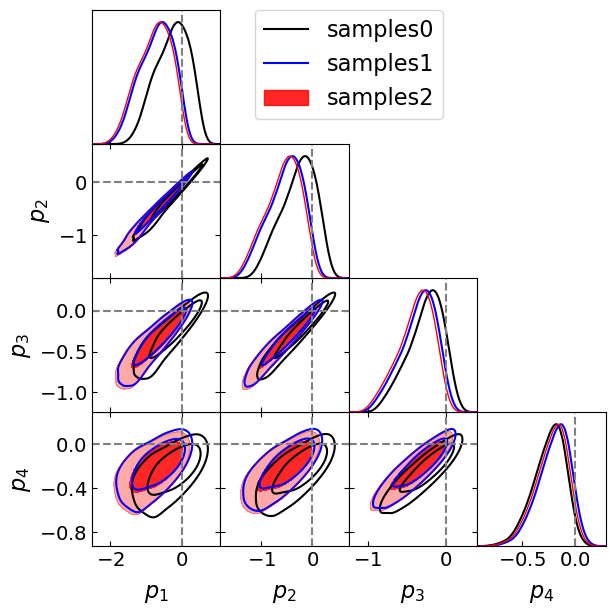

In [120]:
import getdist
from getdist import plots, MCSamples
# samples = MCSamples(samples=Pmm_ratio_all_samp_sel)
g = plots.getSinglePlotter(width_inch=6.25, ratio=1.0)
# g.settings.auto_ticks = True
g.settings.axes_fontsize   = 18
g.settings.lab_fontsize    = 20
g.settings.legend_fontsize = 20
g.settings.axis_marker_lw = 1.5
g.settings.num_plot_contours = 2

# diff_chain_owls_agn = MCSamples(samples=log_YM_diff_owls_agn)
# diff_chain_owls_ref = MCSamples(samples=log_YM_diff_owls_ref)
# diff_chain_b12 = MCSamples(samples=log_YM_diff_B12)

diff_chain_owls_agn = MCSamples(samples=diff_samps3)
diff_chain_owls_ref = MCSamples(samples=diff_samps2)
diff_chain_b12 = MCSamples(samples=diff_samps1)


g.triangle_plot(
    [diff_chain_owls_agn, diff_chain_owls_ref, diff_chain_b12], 
            contour_lws=[1.5, 1.5, 1.0], filled = [False, False,True, True, True], contour_colors = ['black','blue','red','orange','green'],
            ls=['-','-','','',''], markers=np.zeros(YM_ratio_all_samp_sel.shape[-1]))
import matplotlib
%matplotlib inline
pl.show()




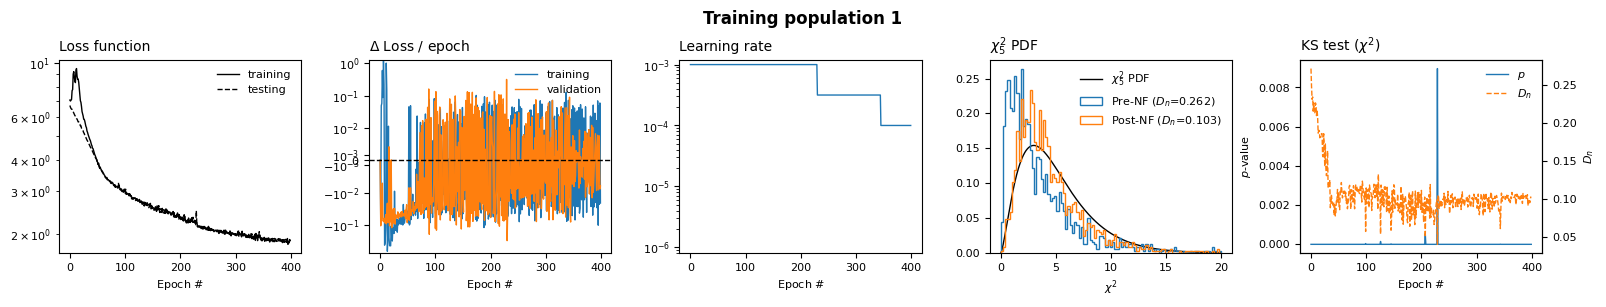

20/20 - 1s - loss: 1.8708 - val_loss: 1.8754 - lr: 1.0000e-04 - 893ms/epoch - 45ms/step
* Population optimizer:
    - best model is number 1
    - best loss function is 1.87
    - best validation loss function is 1.88
    - population losses [1.88]
Shift probability considering all parameters:
    P = 0.89418 +-0.00098 --0.00097
    n_sigma = 1.617 +-0.005 --0.005


In [25]:
# import tensiometer
import sys, os
os.environ['TF_USE_LEGACY_KERAS'] = "1"
from tensiometer import mcmc_tension
from getdist import MCSamples
import numpy as np
# diff_chain = MCSamples(samples=np.random.randn(1000,10))
kwargs = {
          'feedback': 2,  # verbosity level
          'pop_size': 1,  # controls the number of flows that are trained. The best one is then selected. Since time to solution scales linearly with pop_size, it is a good idea to set it to 1 for a first run. 
          'epochs':400,
          'plot_every': 50
        }

# call the helper function:
results, diff_flow = mcmc_tension.flow_parameter_shift(diff_chain_owls_ref,   # parameter difference chain
                                      cache_dir=None,  # directory where the trained flow is saved, to save time next time
                                      root_name='sprob',  # name of the cached flow (usefull to have several in the same folder)
                                      **kwargs
                                      )

# unpack results:
shift_P, shift_hi, shift_low = results

# from tensiometer.utilities import stats_utilities as utilities
import tensiometer.utilities as utilities
print(f'Shift probability considering all parameters:\n',
      f'   P = {shift_P:.5f} +{shift_hi-shift_P:.5f} -{shift_P-shift_low:.5f}')
# turn the result to effective number of sigmas:
print(f'    n_sigma = {utilities.from_confidence_to_sigma(shift_P):.3f}',
      f'+{utilities.from_confidence_to_sigma(shift_hi)-utilities.from_confidence_to_sigma(shift_P):.3f}',
      f'-{utilities.from_confidence_to_sigma(shift_P)-utilities.from_confidence_to_sigma(shift_low):.3f}')
      


In [48]:
# pl.figure()
# pl.plot()
pk_diff_owls.shape


(4,)

In [49]:
chi2_owls, chi2_mtng, chi2_flamingo


(np.float64(26.372582707871572),
 np.float64(24.765886321465885),
 np.float64(14.179875642934697))

In [50]:
# pk_diff_owls.shape
chi2_owls, chi2_mtng, chi2_flamingo
# pk_diff_owls.shape


(np.float64(26.372582707871572),
 np.float64(24.765886321465885),
 np.float64(14.179875642934697))

In [97]:
pk_diff_owls_samp.shape


(373, 4)

(-0.5, 0.1)

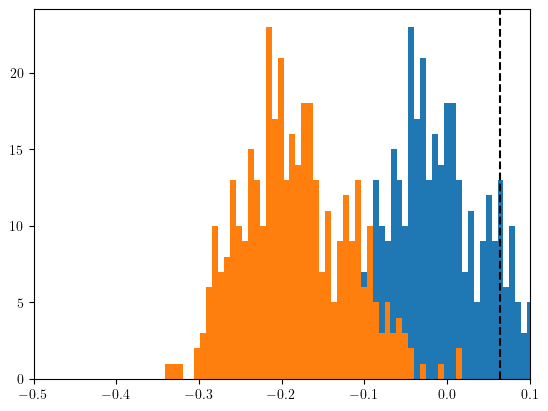

In [77]:
pl.figure()
_  = pl.hist(pk_diff_owls_samp[:,-1], bins=50)
_  = pl.hist(pk_diff_mtng_samp[:,-1], bins=50)
pl.axvline(Pk_ratio_std[-1], color='k', linestyle='--')
pl.xlim(-0.5, 0.1)

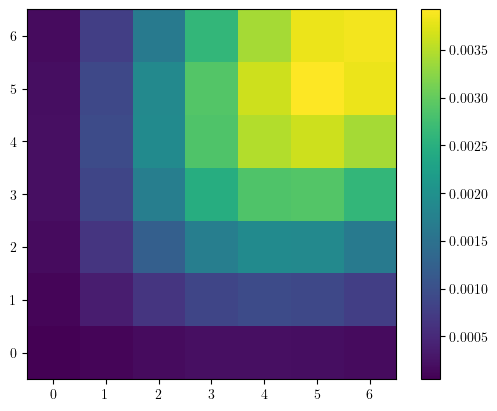

In [32]:
pl.figure()
pl.imshow(((Pmm_ratio_all_samp_sel_cov)), origin='lower')
pl.colorbar()

